In [87]:
from google.colab import files
uploaded = files.upload()

In [88]:
import matplotlib.pyplot as plt
import numpy as np

In [89]:
data = np.genfromtxt("Salary_dataset.csv", delimiter=",", skip_header=1)

In [90]:
x = data[:, 1]
y = data[:, 2]

In [91]:
theta = np.zeros(2)
theta

array([0., 0.])

In [92]:
def visualize(theta, x, y):
  plt.scatter(x, y)
  x_line = np.linspace(0, 12, 100)
  y_line = theta[1]*x_line + theta[0]
  plt.ylim(-5000, 140000)
  plt.xlim(left = 0)
  plt.plot(x_line,y_line)
  plt.show()

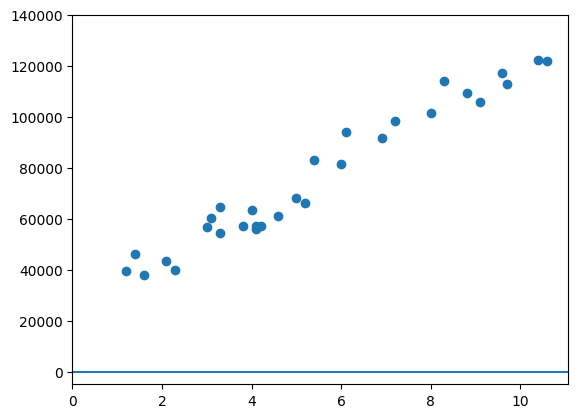

In [93]:
visualize(theta, x, y)

In [94]:
def predict(x, theta):
  y = theta[0] + theta[1]*x
  return y

In [95]:
def fit(x, y, theta, alpha, num_iters):
  m = x.shape[0]
  theta = np.zeros(2)
  for i in range(num_iters):
    y_pred = predict(x, theta)
    theta1 = (1/m)*np.sum(x*(y_pred - y))
    theta0 = (1/m)*np.sum(y_pred - y)

    theta[1] = theta[1] - alpha*theta1
    theta[0] = theta[0] - alpha*theta0
  return theta

In [96]:
finetuned_theta = fit(x, y, theta, 0.01, 1000)
print(finetuned_theta)

[21912.58918422  9880.81400461]


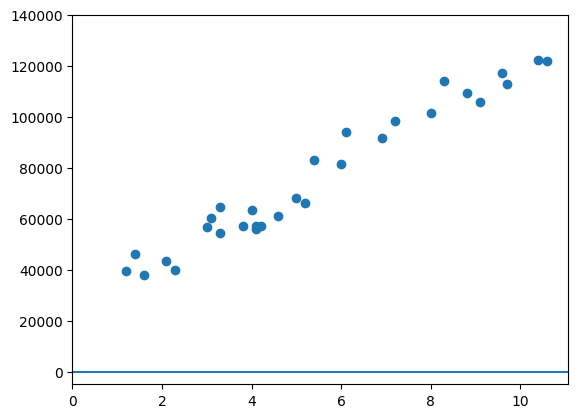

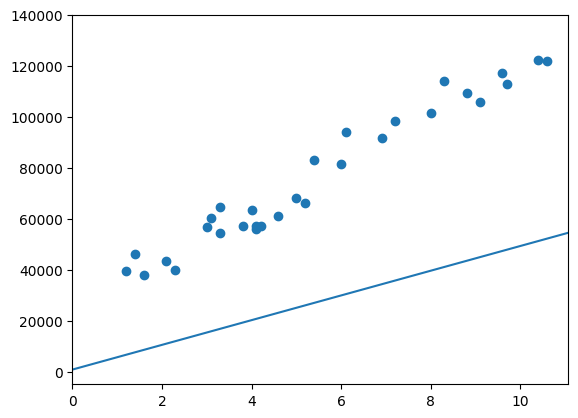

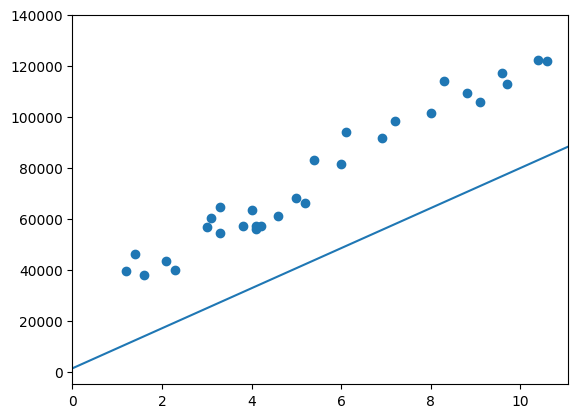

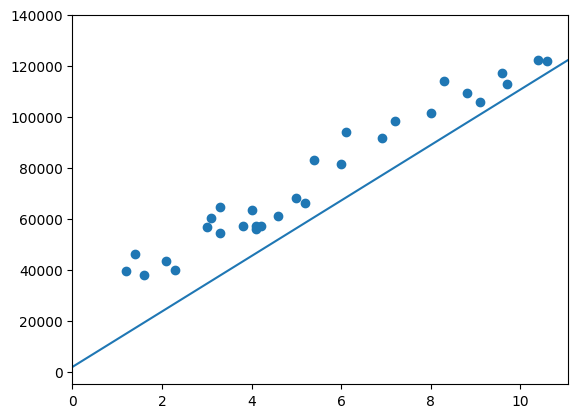

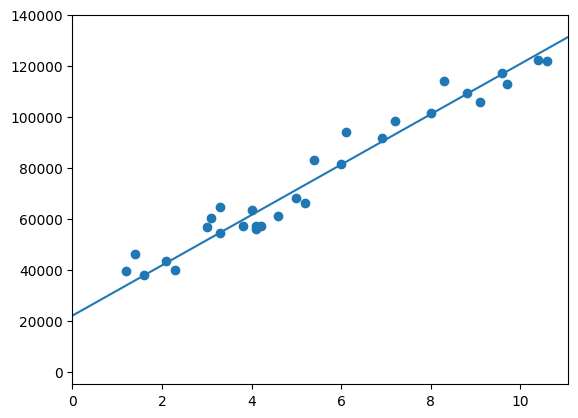

In [97]:
visualize(fit(x, y, theta, 0.01, 0), x, y)
visualize(fit(x, y, theta, 0.01, 1), x, y)
visualize(fit(x, y, theta, 0.01, 2), x, y)
visualize(fit(x, y, theta, 0.01, 4), x, y)
visualize(fit(x, y, theta, 0.01, 1000), x, y)

In [98]:
def cost(x, y, theta):
  m = x.shape[0]
  y_pred = predict(x, theta)
  err = y_pred - y
  cost = np.sum(err ** 2)*(1/(2*m))
  return cost

In [99]:
cost_for_theta_zero = cost(x, y, [0, 0])
print(cost_for_theta_zero)

3251553638.866667


In [106]:
def fit_with_cost(x, y, theta, alpha, num_iters):
  m = x.shape[0]
  j_history = []

  for itr in range(num_iters):
    y_pred = predict(x, theta)
    loss = y_pred - y
    theta1 = (1/m)*np.sum(x*(loss))
    theta0 = (1/m)*np.sum(loss)
    theta[1] = theta[1] - alpha*theta1
    theta[0] = theta[0] - alpha*theta0
    j_history.append(cost(x, y, theta))
  return (theta, j_history)

In [ ]:
theta = np.zeros(2)
theta, j_history = fit_with_cost(x, y, theta, 0.001, 100)

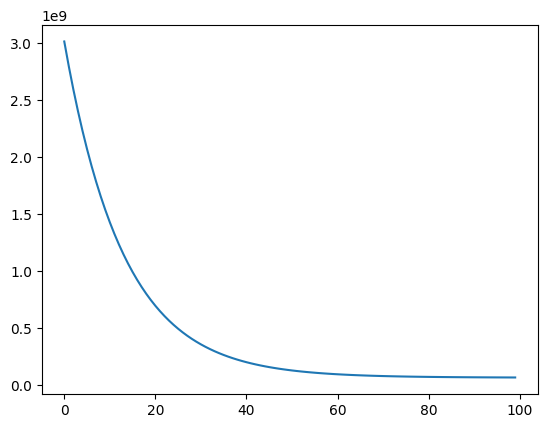

In [108]:
plt.plot(j_history)